# Cantidad neta semanal ERP y corte estricto
Se conserva `cantidad` en la escala registrada por el ERP, sin convertir cajas a unidades, sin sumar `cantidad + unidades` y sin normalizar el target. MAE/RMSE están en esa escala. Los negativos muestran patrones compatibles con anulaciones, devoluciones o ajustes operativos; no se afirma que todos sean devoluciones.

El constructor compartido suma primero todas las transacciones positivas y negativas por sucursal-producto y semana `W-SUN`. Conserva `cantidad_neta_original` y define `cantidad = max(cantidad_neta_original, 0)` para modelar. Un saldo neto negativo no se interpreta como demanda negativa. Los NaN siguen provocando error; sólo se rellenan huecos interiores sin transacciones, bajo el supuesto de continuidad del sistema.

El corte sigue siendo **2026-01-01**. Se excluye de la evaluación la semana 2025-12-29 a 2026-01-04 en todas las series, incluso si sólo registra transacciones de enero. El test comienza con semanas completas posteriores (etiqueta 2026-01-11). Las semanas de los extremos del dataset pueden ser parciales.


El holdout usa semanas etiquetadas antes de `2026-01-01` para desarrollo y desde esa fecha para test. Como una semana termina en domingo, la primera semana de test es 2026-01-04 e incluye el 29–31 de diciembre. El último bloque puede contener una semana parcial de agosto, aunque las transacciones terminan en julio. Se reportan ambos rangos sin reasignar transacciones ni cortar semanas silenciosamente.

In [2]:
import sys
import json
import hashlib
import platform
from pathlib import Path
import importlib.metadata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

sys.path.insert(0, str(Path('..').resolve()))
from src.preprocessing.demanda_semanal import (
    CLAVES, NUMERICAS, construir_semanal, agregar_features, particiones_por_semana, excluir_semana_corte)

ruta_datos = Path('../datasets/dataset_maestro_dashboard.csv')
salida = Path('../resultados/semanal')
salida.mkdir(parents=True, exist_ok=True)
fecha_corte = '2026-01-01'
df = pd.read_csv(ruta_datos)
df['fecdoc'] = pd.to_datetime(df['fecdoc'], errors='raise')
resumen_original = {
    'registros_transaccionales': len(df),
    'inicio': str(df.fecdoc.min()), 'fin': str(df.fecdoc.max()),
    'sucursales': int(df.sucursal.nunique()), 'productos': int(df.producto.nunique()),
    'combinaciones_potenciales': int(df.sucursal.nunique() * df.producto.nunique()),
    'combinaciones_observadas': int(df.groupby(CLAVES).ngroups),
    'sha256_dataset': hashlib.sha256(ruta_datos.read_bytes()).hexdigest()
}
display(pd.DataFrame([resumen_original]))

semanal = construir_semanal(df)
semanal.to_csv(salida / 'dataset_semanal.csv', index=False)
print('Observaciones semanales:', len(semanal))
print('Rango semanal:', semanal.semana.min(), semanal.semana.max())
semanal_evaluable, semanas_excluidas = excluir_semana_corte(semanal, fecha_corte)
semanal_evaluable.to_csv(salida / 'dataset_semanal_evaluable.csv', index=False)
semanas_excluidas.to_csv(salida / 'semanas_excluidas_corte.csv', index=False)
print('Observaciones excluidas por cruce del corte:', len(semanas_excluidas))

,registros_transaccionales,inicio,fin,sucursales,productos,combinaciones_potenciales,combinaciones_observadas,sha256_dataset
0,44389,2024-01-01 00:00:00,2026-07-30 22:20:28,19,14,266,240,d57f432caea468ab5599dc0a73b2bdf0a5ac63ece3d505...


Observaciones semanales: 21123
Rango semanal: 2024-01-07 00:00:00 2026-08-02 00:00:00
Observaciones excluidas por cruce del corte: 144


## Evidencia original y target de modelado
`cantidad_neta_original` conserva el saldo operativo, incluidos saldos semanales negativos. `cantidad` conserva la escala ERP pero trunca esos saldos a cero después de sumar. El EDA 08 conserva los negativos transaccionales, los contextos operativos y la distribución de ambas variables. Un registro con cantidad cero y unidades positivas no equivale a venta cero. No se convierten unidades ni se normaliza cantidad.

,completo_cantidad_neta_original,completo_cantidad,evaluable_cantidad_neta_original,evaluable_cantidad
count,21123.000000,21123.000000,20979.000000,20979.000000
mean,0.149884,0.150405,0.150245,0.150770
std,0.577957,0.573669,0.578989,0.574679
min,-10.000000,0.000000,-10.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
max,14.000000,14.000000,14.000000,14.000000
median,0.000000,0.000000,0.000000,0.000000
porcentaje_ceros,90.455901,90.465370,90.438057,90.447590


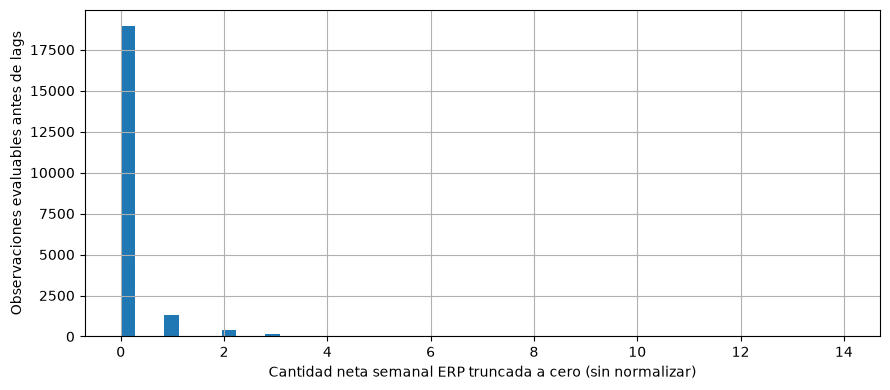

In [3]:
descriptivos = pd.DataFrame()
for universo, marco in [('completo', semanal), ('evaluable', semanal_evaluable)]:
    for variable in ['cantidad_neta_original', 'cantidad']:
        valores = marco[variable]
        resumen = valores.describe()
        resumen['median'] = valores.median()
        resumen['porcentaje_ceros'] = valores.eq(0).mean() * 100
        resumen['valores_positivos'] = valores.gt(0).sum()
        resumen['valores_negativos'] = valores.lt(0).sum()
        descriptivos[f'{universo}_{variable}'] = resumen
display(descriptivos)
descriptivos.to_csv(salida / 'descriptivos_semanales.csv')
semanal_evaluable.cantidad.hist(bins=50, figsize=(9,4))
plt.xlabel('Cantidad neta semanal ERP truncada a cero (sin normalizar)')
plt.ylabel('Observaciones evaluables antes de lags')
plt.tight_layout()
plt.show()

## Características causales y eliminación del historial insuficiente
`lag_1`, `lag_2`, `lag_4` y `lag_8` son demandas de 1, 2, 4 y 8 semanas anteriores dentro de la misma sucursal-producto. Las medias de 4 y 8 semanas usan `shift(1)` y requieren la ventana completa. Mes, semana ISO y trimestre provienen del calendario de la semana a pronosticar.

Se eliminan las primeras ocho semanas de cada serie (o toda la serie si no supera ocho observaciones). Se informa el número exacto, separado por train/test. Las features del test utilizan únicamente semanas anteriores: este es un protocolo secuencial de una semana con parámetros fijos durante el test; no es una predicción simultánea de todo 2026 desde enero. La misma disponibilidad secuencial se aplica dentro de cada bloque de validación.
Se calculan lags sobre el calendario completo ANTES de excluir la semana cruzada del scoring: eliminarla antes comprimiría el calendario y falsearía lag_1. En la predicción del 11 de enero puede usarse el saldo del 4 de enero, que ya se conoce al terminar esa semana; ninguna transacción de diciembre se suma al TARGET de test. La exclusión es de evaluación, no una eliminación de historia ya disponible. Se reportan eliminaciones por lags tanto en el calendario completo como en el universo evaluable, sin contar dos veces las exclusiones.

In [4]:
con_features = agregar_features(semanal)
features_evaluables, _ = excluir_semana_corte(con_features, fecha_corte)
sin_historia = con_features[NUMERICAS].isna().any(axis=1)
con_historia = con_features.loc[~sin_historia]
datos_modelo, _ = excluir_semana_corte(con_historia, fecha_corte)
datos_modelo = datos_modelo.sort_values(
    ['semana', 'sucursal', 'producto'], kind='stable').reset_index(drop=True)
df_train = datos_modelo[datos_modelo.semana < fecha_corte].copy()
df_test = datos_modelo[datos_modelo.semana >= fecha_corte].copy()
assert not df_train.empty and not df_test.empty
assert df_train.semana.max() < df_test.semana.min()
resumen_semanal = {
    'observaciones_semanales': len(semanal),
    'train_antes_lags': int(semanal_evaluable.semana.lt(fecha_corte).sum()),
    'test_antes_lags': int(semanal_evaluable.semana.ge(fecha_corte).sum()),
    'eliminadas_por_lags_calendario_completo': int(sin_historia.sum()),
    'eliminadas_por_lags': int(features_evaluables[NUMERICAS].isna().any(axis=1).sum()),
    'excluidas_corte': len(semanas_excluidas),
    'observaciones_evaluables': len(semanal_evaluable),
    'eliminadas_train': int((sin_historia & con_features.semana.lt(fecha_corte)).sum()),
    'eliminadas_test': int((features_evaluables[NUMERICAS].isna().any(axis=1) & features_evaluables.semana.ge(fecha_corte)).sum()),
    'train_modelo': len(df_train), 'test_modelo': len(df_test),
    'series_con_historia': int(datos_modelo.groupby(CLAVES).ngroups),
    'series_test': int(df_test.groupby(CLAVES).ngroups),
    'porcentaje_ceros_completo': float(semanal.cantidad.eq(0).mean() * 100),
    'porcentaje_ceros_evaluable': float(semanal_evaluable.cantidad.eq(0).mean() * 100),
    'inicio_semanal': str(semanal.semana.min()), 'fin_semanal': str(semanal.semana.max())
}
display(pd.DataFrame([resumen_semanal]))
X_train = df_train[CLAVES + NUMERICAS]
X_test = df_test[CLAVES + NUMERICAS]
y_train, y_test = df_train.cantidad, df_test.cantidad
print('Dimensiones antes de One-Hot:', X_train.shape, X_test.shape)
for columna in CLAVES:
    nuevas = sorted(set(X_test[columna]) - set(X_train[columna]))
    print(f'Categorías de {columna} presentes sólo en TEST:', nuevas)

assert (df_test.semana - pd.Timedelta(days=6) >= pd.Timestamp(fecha_corte)).all()
assert len(semanal_evaluable) == len(df_train) + len(df_test) + resumen_semanal['eliminadas_por_lags']

,observaciones_semanales,train_antes_lags,test_antes_lags,eliminadas_por_lags_calendario_completo,eliminadas_por_lags,excluidas_corte,observaciones_evaluables,eliminadas_train,eliminadas_test,train_modelo,test_modelo,series_con_historia,series_test,porcentaje_ceros_completo,porcentaje_ceros_evaluable,inicio_semanal,fin_semanal
0,21123,16860,4119,1881,1869,144,20979,1690,179,15170,3940,232,156,90.46537,90.44759,2024-01-07 00:00:00,2026-08-02 00:00:00


Dimensiones antes de One-Hot: (15170, 11) (3940, 11)
Categorías de sucursal presentes sólo en TEST: [17, 18, 19]
Categorías de producto presentes sólo en TEST: []


Cargando base de datos...
TOP 5 SUCURSALES CON MAYOR DEMANDA:
sucursal
5    397.0
1    352.0
2    317.0
3    283.0
4    278.0
Name: cantidad, dtype: float64
--------------------------------------------------
TOP 5 SUCURSALES CON MENOR DEMANDA (Más propensas a intermitencia):
sucursal
18     4.0
19    20.0
17    30.0
8     68.0
13    69.0
Name: cantidad, dtype: float64


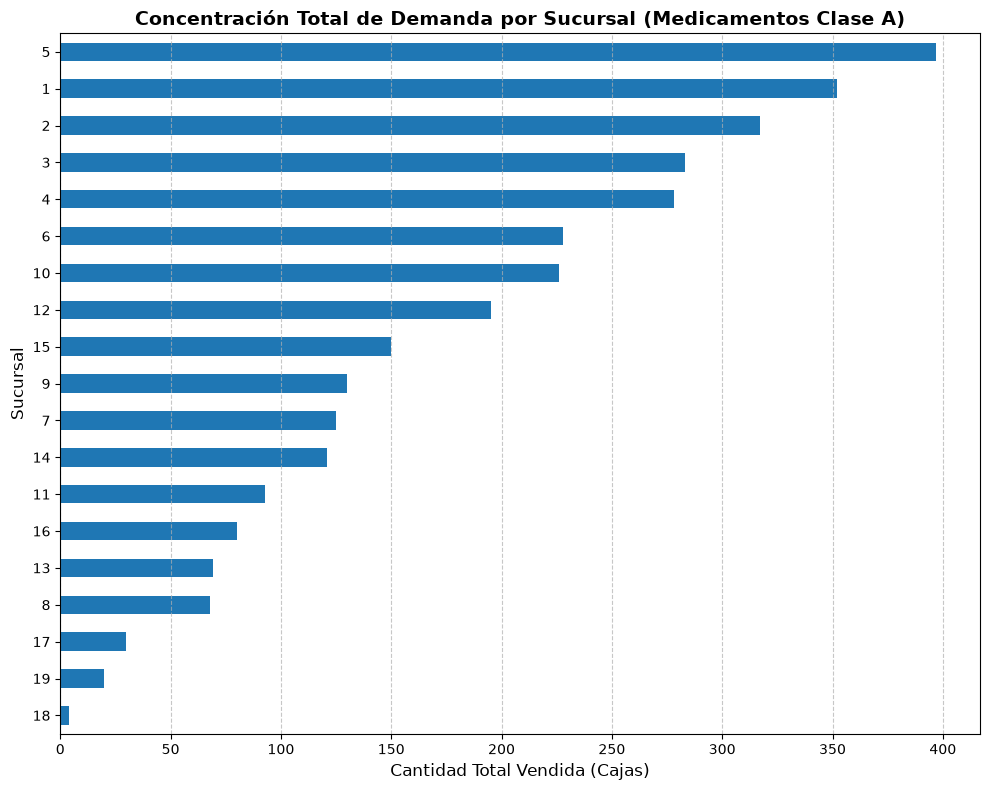

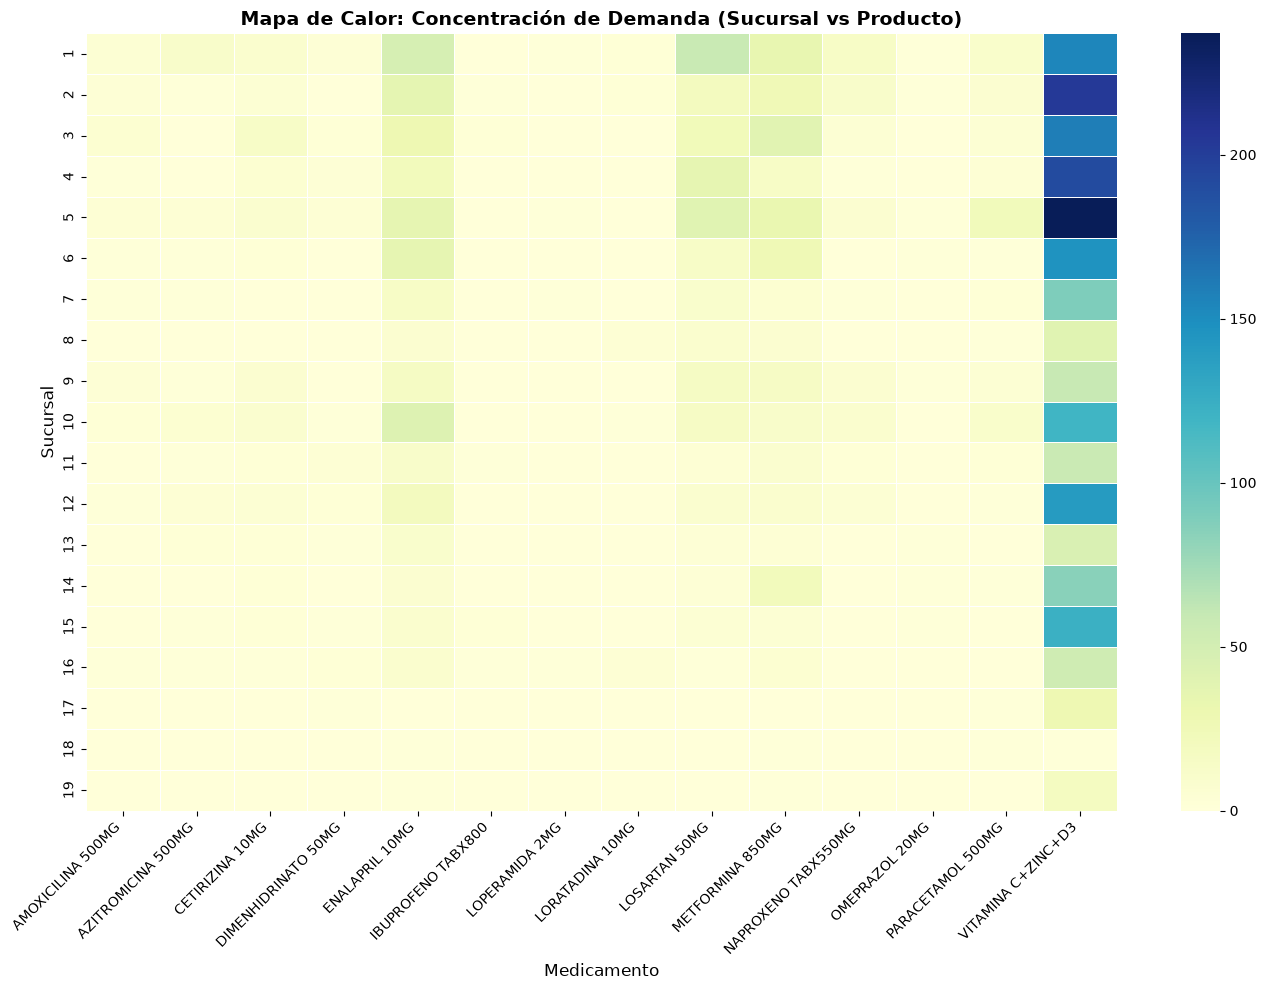

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset maestro
print("Cargando base de datos...")
df = pd.read_csv("../datasets/dataset_maestro_dashboard.csv")

# 2. Calcular la demanda total por sucursal
demanda_sucursal = df.groupby('sucursal')['cantidad'].sum().sort_values(ascending=True)

print("TOP 5 SUCURSALES CON MAYOR DEMANDA:")
print(demanda_sucursal.tail(5).sort_values(ascending=False))
print("-" * 50)
print("TOP 5 SUCURSALES CON MENOR DEMANDA (Más propensas a intermitencia):")
print(demanda_sucursal.head(5))

# 3. Graficar el volumen total por sucursal
plt.figure(figsize=(10, 8))
demanda_sucursal.plot(kind='barh', color='#1f77b4')
plt.title('Concentración Total de Demanda por Sucursal (Medicamentos Clase A)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad Total Vendida (Cajas)', fontsize=12)
plt.ylabel('Sucursal', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Matriz de calor (Heatmap): Sucursal vs Medicamento
# Esto muestra exactamente qué medicamento se vende más en qué sucursal
matriz_demanda = df.pivot_table(index='sucursal', columns='producto', values='cantidad', aggfunc='sum', fill_value=0)

plt.figure(figsize=(14, 10))
sns.heatmap(matriz_demanda, cmap='YlGnBu', linewidths=.5, fmt=".0f", annot=False)
plt.title('Mapa de Calor: Concentración de Demanda (Sucursal vs Producto)', fontsize=14, fontweight='bold')
plt.xlabel('Medicamento', fontsize=12)
plt.ylabel('Sucursal', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Validación temporal y categorías
Se usa `TimeSeriesSplit(n_splits=3)` sobre las semanas únicas del train y se convierten sus posiciones a filas para `GridSearchCV`. Así ninguna semana se reparte entre entrenamiento y validación, aunque contenga varias sucursales. No hay shuffle ni selección con test.

El One-Hot Encoder está dentro del Pipeline: se ajusta sólo con el entrenamiento de cada fold y, en el ajuste final, sólo con todo TRAIN. TEST utiliza ese mismo transformador. Categorías desconocidas se representan con ceros (`handle_unknown='ignore'`); la categoría de referencia se omite (`drop='first'`). Se conservan categorías conocidas sin consultar el futuro. La selección minimiza MSE de validación (`best_score_` es MSE negativo), con rejillas moderadas y semilla 42.

In [6]:
class MachineLearningPipeline:
    def __init__(self, X_train, y_train, X_test, y_test, fechas_train, claves_test):
        self.X_train, self.y_train = X_train, y_train
        self.X_test, self.y_test = X_test, y_test
        self.claves_test = claves_test.copy()
        self.resultados, self.predicciones, self.modelos = [], {}, {}
        self.best_params_, self.best_score_, self.cv_results_ = {}, {}, {}
        self.cv = particiones_por_semana(fechas_train, n_splits=3)

    def _pipeline(self, modelo):
        preprocesador = ColumnTransformer([
            ('categorias', OneHotEncoder(handle_unknown='ignore', drop='first',
                                          sparse_output=False), CLAVES),
            ('numericas', 'passthrough', NUMERICAS)
        ])
        return Pipeline([('preprocesador', preprocesador), ('modelo', modelo)])

    def _registrar_metricas(self, nombre_modelo, predicciones):
        detalle = self.claves_test.copy()
        detalle['y_real'] = np.asarray(self.y_test, dtype=float)
        detalle['y_pred'] = np.asarray(predicciones, dtype=float)
        if not np.isfinite(detalle[['y_real', 'y_pred']]).all().all():
            raise ValueError('Valores no finitos en la evaluación')
        detalle['error'] = detalle.y_real - detalle.y_pred
        detalle['error_absoluto'] = detalle.error.abs()
        self.predicciones[nombre_modelo] = detalle
        self.resultados.append({
            'Modelo': nombre_modelo,
            'MAE': mean_absolute_error(detalle.y_real, detalle.y_pred),
            'RMSE': np.sqrt(mean_squared_error(detalle.y_real, detalle.y_pred)),
            'R2': r2_score(detalle.y_real, detalle.y_pred),
            'Best Params': self.best_params_.get(nombre_modelo, {}),
            'CV neg_MSE': self.best_score_.get(nombre_modelo, np.nan)
        })

    def ejecutar_regresion_lineal(self):
        nombre = 'Regresión Lineal'
        modelo = self._pipeline(LinearRegression())
        modelo.fit(self.X_train, self.y_train)
        self.modelos[nombre] = modelo
        self._registrar_metricas(nombre, modelo.predict(self.X_test))

    def _buscar(self, nombre, estimador, rejilla):
        grid = GridSearchCV(self._pipeline(estimador),
                            {f'modelo__{k}': v for k, v in rejilla.items()},
                            cv=self.cv, scoring='neg_mean_squared_error',
                            n_jobs=1, error_score='raise', refit=True)
        grid.fit(self.X_train, self.y_train)
        self.modelos[nombre] = grid.best_estimator_
        self.best_params_[nombre] = {k.removeprefix('modelo__'): v for k, v in grid.best_params_.items()}
        self.best_score_[nombre] = float(grid.best_score_)
        self.cv_results_[nombre] = pd.DataFrame(grid.cv_results_)
        print(nombre, 'best_params_:', self.best_params_[nombre])
        print(nombre, 'best_score_ (MSE negativo):', grid.best_score_)
        self._registrar_metricas(nombre, grid.predict(self.X_test))

    def ejecutar_random_forest(self):
        self._buscar('Random Forest', RandomForestRegressor(random_state=42, n_jobs=-1), {
            'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_leaf': [1, 2]})

    def ejecutar_xgboost(self):
        self._buscar('XGBoost', XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1), {
            'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]})

    def obtener_tabla_resultados(self):
        return pd.DataFrame(self.resultados).sort_values('RMSE').reset_index(drop=True)

pipeline = MachineLearningPipeline(X_train, y_train, X_test, y_test,
                                   df_train.semana, df_test[CLAVES + ['semana']])
folds = []
for i, (a, b) in enumerate(pipeline.cv, 1):
    folds.append({'fold': i, 'filas_train': len(a), 'filas_validacion': len(b),
                  'train_inicio': str(df_train.semana.iloc[a].min()),
                  'train_fin': str(df_train.semana.iloc[a].max()),
                  'validacion_inicio': str(df_train.semana.iloc[b].min()),
                  'validacion_fin': str(df_train.semana.iloc[b].max())})
display(pd.DataFrame(folds))

,fold,filas_train,filas_validacion,train_inicio,train_fin,validacion_inicio,validacion_fin
0,1,2967,3732,2024-03-03 00:00:00,2024-08-11 00:00:00,2024-08-18 00:00:00,2025-01-26 00:00:00
1,2,6699,4357,2024-03-03 00:00:00,2025-01-26 00:00:00,2025-02-02 00:00:00,2025-07-13 00:00:00
2,3,11056,4114,2024-03-03 00:00:00,2025-07-13 00:00:00,2025-07-20 00:00:00,2025-12-28 00:00:00


In [8]:
pipeline.ejecutar_regresion_lineal()
pipeline.ejecutar_random_forest()
pipeline.ejecutar_xgboost()
tabla_final = pipeline.obtener_tabla_resultados()
display(tabla_final)
tabla_final.to_csv(salida / 'metricas_ml_semanal.csv', index=False)
for nombre, detalle in pipeline.predicciones.items():
    detalle.to_csv(salida / f'predicciones_{nombre.replace(" ", "_")}_semanal.csv', index=False)
for nombre, resultados_cv in pipeline.cv_results_.items():
    resultados_cv.to_csv(salida / f'cv_{nombre.replace(" ", "_")}.csv', index=False)

versiones = {p: importlib.metadata.version(p) for p in
             ['pandas', 'numpy', 'scikit-learn', 'xgboost', 'statsmodels', 'joblib']}
manifiesto = {'version_target': 'neto_erp_no_negativo_corte_estricto_v1',
              'sha256_constructor': hashlib.sha256(Path('../src/preprocessing/demanda_semanal.py').read_bytes()).hexdigest(),
              'dataset_original': resumen_original, 'dataset_semanal': resumen_semanal,
              'fecha_corte': fecha_corte, 'frecuencia': 'W-SUN',
              'protocolo_ml': 'una semana secuencial; sin reentrenar durante test',
              'folds': folds, 'best_params': pipeline.best_params_,
              'best_score_neg_mse': pipeline.best_score_,
              'python': platform.python_version(), 'versiones': versiones}
(salida / 'experimento_ml.json').write_text(json.dumps(manifiesto, indent=2, ensure_ascii=False), encoding='utf-8')
print('Resultados y predicciones guardados en', salida.resolve())
(salida / 'best_params.json').write_text(json.dumps(pipeline.best_params_, indent=2), encoding='utf-8')

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg,

Random Forest best_params_: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 200}
Random Forest best_score_ (MSE negativo): -0.23944511112367564


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg,

XGBoost best_params_: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
XGBoost best_score_ (MSE negativo): -0.22442686983335566


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,Modelo,MAE,RMSE,R2,Best Params,CV neg_MSE
0,Regresión Lineal,0.212622,0.506496,0.326472,{},NaN
1,XGBoost,0.205575,0.514015,0.306326,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",-0.224427
2,Random Forest,0.207197,0.517482,0.296937,"{'max_depth': 10, 'min_samples_leaf': 2, 'n_es...",-0.239445


Resultados y predicciones guardados en C:\Users\USER\Desktop\Project-LF\Modelos_ML\resultados\semanal


191

## Interpretación y serialización
MAE resume error absoluto medio; RMSE penaliza errores grandes y R² compara con predecir la media del test. Las métricas se calculan sobre exactamente las mismas filas de test en los tres modelos supervisados y no se redondean internamente. No se recortan predicciones negativas.

La tabla ordenada por RMSE no declara un ganador general del estudio. Se informa el contraste de las tres métricas. Como regla conservadora para guardar el nuevo artefacto XGBoost, se exige que tenga el menor RMSE, el mayor R² y no empeore el menor MAE de los tres modelos. Esto no ajusta hiperparámetros con test: sólo decide si se guarda el estimador ya evaluado. El archivo anterior permanece intacto. Se guarda el Pipeline completo entrenado sólo con TRAIN, sin reentrenarlo con el test y sin atribuirle métricas de un ajuste diferente.

ARIMA conserva evaluación de horizonte múltiple y filtros de longitud propios. Antes de afirmar superioridad entre los cuatro modelos habría que emparejar también horizonte y cobertura, no sólo frecuencia. El cuaderno 06 presenta sus métricas consolidadas por separado.

In [9]:
tabla = tabla_final.set_index('Modelo')
xgb = tabla.loc['XGBoost']
print('Menor MAE:', tabla.MAE.idxmin())
print('Menor RMSE:', tabla.RMSE.idxmin())
print('Mayor R2:', tabla.R2.idxmax())
if xgb.RMSE <= tabla.RMSE.min() and xgb.R2 >= tabla.R2.max() and xgb.MAE <= tabla.MAE.min():
    ruta_modelo = Path('modelo_xgb_optimo_semanal.pkl')
    joblib.dump(pipeline.modelos['XGBoost'], ruta_modelo)
    print('Guardado Pipeline semanal entrenado sólo en TRAIN:', ruta_modelo)
else:
    print('No se serializa XGBoost: no domina conjuntamente las tres métricas.')

Menor MAE: XGBoost
Menor RMSE: Regresión Lineal
Mayor R2: Regresión Lineal
No se serializa XGBoost: no domina conjuntamente las tres métricas.


## Comparación descriptiva de los cuatro modelos
Se verifica que las ejecuciones comparten CSV, constructor y versión de target antes de combinar resultados. ARIMA mantiene multi-step desde origen fijo; ML es secuencial con historia disponible semana a semana. La cobertura depende de los filtros propios. Los mínimos/máximos se identifican descriptivamente, no se declara un ganador causal ni una comparación perfectamente emparejada.

In [10]:
arima_info = json.loads((salida / 'experimento_arima.json').read_text(encoding='utf-8'))
assert arima_info['version_target'] == manifiesto['version_target']
assert arima_info['sha256_dataset'] == resumen_original['sha256_dataset']
assert arima_info['sha256_constructor'] == manifiesto['sha256_constructor']
comparacion_ml = tabla_final[['Modelo','MAE','RMSE','R2']].copy()
comparacion_ml['Granularidad'] = 'Semanal W-SUN sucursal-producto'
comparacion_ml['Observaciones_evaluadas'] = len(df_test)
comparacion_ml['Protocolo'] = 'Secuencial semanal, parámetros fijos'
comparacion_arima = pd.read_csv(salida / 'metricas_arima.csv')
comparacion_arima['Granularidad'] = 'Semanal W-SUN sucursal-producto'
comparacion_arima['Observaciones_evaluadas'] = arima_info['observaciones_evaluadas']
comparacion_arima['Protocolo'] = 'Multi-step desde origen fijo'
comparacion = pd.concat([comparacion_ml, comparacion_arima], ignore_index=True)
comparacion.to_csv(salida / 'comparacion_modelos.csv', index=False)
display(comparacion)
for metrica, extremo in [('MAE', comparacion.MAE.min()), ('RMSE', comparacion.RMSE.min()), ('R2', comparacion.R2.max())]:
    print(metrica, 'extremo favorable:', comparacion.loc[comparacion[metrica].eq(extremo), 'Modelo'].tolist())
print('Diferencias de protocolo y cobertura impiden declarar un ganador general.')

,Modelo,MAE,RMSE,R2,Granularidad,Observaciones_evaluadas,Protocolo
0,Regresión Lineal,0.212622,0.506496,0.326472,Semanal W-SUN sucursal-producto,3940,"Secuencial semanal, parámetros fijos"
1,XGBoost,0.205575,0.514015,0.306326,Semanal W-SUN sucursal-producto,3940,"Secuencial semanal, parámetros fijos"
2,Random Forest,0.207197,0.517482,0.296937,Semanal W-SUN sucursal-producto,3940,"Secuencial semanal, parámetros fijos"
3,ARIMA (Optimizado ADF/AIC),0.231150,0.572762,0.210971,Semanal W-SUN sucursal-producto,3444,Multi-step desde origen fijo


MAE extremo favorable: ['XGBoost']
RMSE extremo favorable: ['Regresión Lineal']
R2 extremo favorable: ['Regresión Lineal']
Diferencias de protocolo y cobertura impiden declarar un ganador general.


## Interpretación y exportación del modelo seleccionado
Se exporta Regresión Lineal por su menor RMSE, respaldado por mayor R², entre los tres modelos ML evaluados. XGBoost conserva el menor MAE; no se afirma superioridad en todas las métricas ni frente a ARIMA con distinto protocolo.

El artefacto contiene el One-Hot Encoder y el estimador ya entrenados sólo con TRAIN. No se reentrena con el test. Se guarda en `modelo_regresion_lineal_semanal.pkl` junto con un JSON de columnas, regla del target, versiones, fechas, métricas y huellas de archivos. La recarga debe reproducir exactamente las predicciones evaluadas. El modelo XGBoost anterior permanece intacto.

El dashboard deberá construir las mismas features semanales con ocho semanas de historia observada y respetar el orden/nombre de columnas. El pickle no realiza la agregación transaccional ni genera por sí solo esos rezagos; sí aplica la codificación categórica. Este artefacto no equivale a un modelo actualizado con toda la historia hasta julio de 2026.


In [11]:
from pathlib import Path
import json
import hashlib
import joblib
import numpy as np

# Ejecutar después del entrenamiento de los tres modelos y de crear tabla_final.
nombre_modelo = 'Regresión Lineal'
tabla = tabla_final.set_index('Modelo')
if nombre_modelo not in pipeline.modelos:
    raise RuntimeError('Primero ejecuta las celdas de entrenamiento del notebook 07.')
if not (tabla.loc[nombre_modelo, 'RMSE'] <= tabla['RMSE'].min()
        and tabla.loc[nombre_modelo, 'R2'] >= tabla['R2'].max()):
    raise ValueError('Esta ejecución no confirma la selección por RMSE y R2; revisar la tabla antes de exportar.')

# Pipeline completo: One-Hot Encoder ajustado en TRAIN + LinearRegression.
# No se vuelve a entrenar con el test ni se sobrescribe el XGBoost anterior.
modelo_exportado = pipeline.modelos[nombre_modelo]
ruta_modelo = Path('modelo_regresion_lineal_semanal.pkl')
joblib.dump(modelo_exportado, ruta_modelo)

# Comprobar que guardar/cargar no cambia ninguna predicción del holdout.
modelo_cargado = joblib.load(ruta_modelo)
np.testing.assert_allclose(
    modelo_cargado.predict(X_test), pipeline.predicciones[nombre_modelo]['y_pred'].to_numpy(),
    rtol=0, atol=0)

metadata = {
    'modelo': nombre_modelo,
    'criterio_seleccion': 'Menor RMSE entre ML, respaldado por mayor R2; XGBoost tiene menor MAE en la ejecución verificada.',
    'entrenado_solo_en_train': True,
    'train_inicio': str(df_train.semana.min()),
    'train_fin': str(df_train.semana.max()),
    'fecha_corte': fecha_corte,
    'target': 'Cantidad neta semanal ERP truncada a cero después de sumar; sin normalización',
    'version_target': manifiesto['version_target'],
    'frecuencia': 'W-SUN',
    'protocolo': 'Secuencial de una semana; requiere ocho semanas previas observadas',
    'columnas_entrada': X_train.columns.tolist(),
    'tipos_entrada': {col: str(tipo) for col, tipo in X_train.dtypes.items()},
    'metricas_holdout': {k: float(tabla.loc[nombre_modelo, k]) for k in ['MAE','RMSE','R2']},
    'observaciones_holdout': len(X_test),
    'sha256_dataset': resumen_original['sha256_dataset'],
    'sha256_constructor': manifiesto['sha256_constructor'],
    'sha256_modelo': hashlib.sha256(ruta_modelo.read_bytes()).hexdigest(),
    'python': manifiesto['python'],
    'versiones': manifiesto['versiones'],
    'predicciones_negativas': 'Se conservan; no se aplica recorte posterior',
    'integracion': 'Crear features con demanda_semanal.py sobre historia semanal completa; pasar sucursal, producto y NUMERICAS. No pasar cantidad_neta_original, cantidad, total o unidades como predictores.'
}
ruta_metadata = ruta_modelo.with_suffix('.json')
ruta_metadata.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding='utf-8')
print('Pipeline guardado:', ruta_modelo.resolve())
print('Metadatos guardados:', ruta_metadata.resolve())
print('Verificación correcta: las predicciones recargadas coinciden exactamente con el holdout.')

Pipeline guardado: C:\Users\USER\Desktop\Project-LF\Modelos_ML\notebooks\modelo_regresion_lineal_semanal.pkl
Metadatos guardados: C:\Users\USER\Desktop\Project-LF\Modelos_ML\notebooks\modelo_regresion_lineal_semanal.json
Verificación correcta: las predicciones recargadas coinciden exactamente con el holdout.


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
